<a href="https://colab.research.google.com/github/Arjun-p88/Zomato_Restaurant_Market_Segmentation/blob/main/Zomato_Restaurant_Market_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Libraries !

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set aesthetic style for charts
sns.set_theme(style="whitegrid")

# Cleaning Dataset

In [ ]:
# Load files
df_meta = pd.read_csv('Zomato Restaurant names and Metadata.csv')
df_reviews = pd.read_csv('Zomato Restaurant reviews.csv')

# Clean Cost (Remove commas, convert to number)
df_meta['Clean_Cost'] = df_meta['Cost'].astype(str).str.replace(',', '').str.extract(r'(\d+)').astype(float)

# Clean Ratings (Ignore bad data, make numeric)
df_reviews['Clean_Rating'] = pd.to_numeric(df_reviews['Rating'], errors='coerce')
df_reviews = df_reviews.dropna(subset=['Clean_Rating', 'Review'])

# Aggregate review ratings per restaurant
avg_ratings = df_reviews.groupby('Restaurant')['Clean_Rating'].mean().reset_index()
avg_ratings.rename(columns={'Clean_Rating': 'Avg_Rating'}, inplace=True)

# Merge datasets
df_merged = pd.merge(df_meta, avg_ratings, left_on='Name', right_on='Restaurant', how='inner')

# Feature scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_merged[['Clean_Cost', 'Avg_Rating']])

# implementing K Means

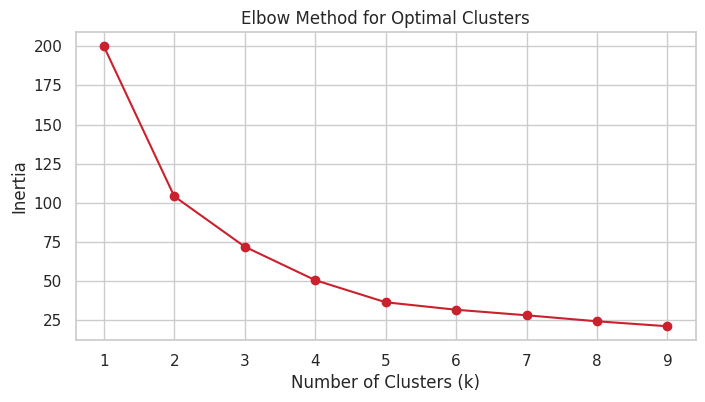

In [ ]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'o-', color='#cb202d') # Zomato Red
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_merged['Cluster'] = kmeans.fit_predict(X_scaled)

# Map human-readable categories to clusters
# Cluster 0, 1, 2 representing Value, Mid-Range, and Premium Dining

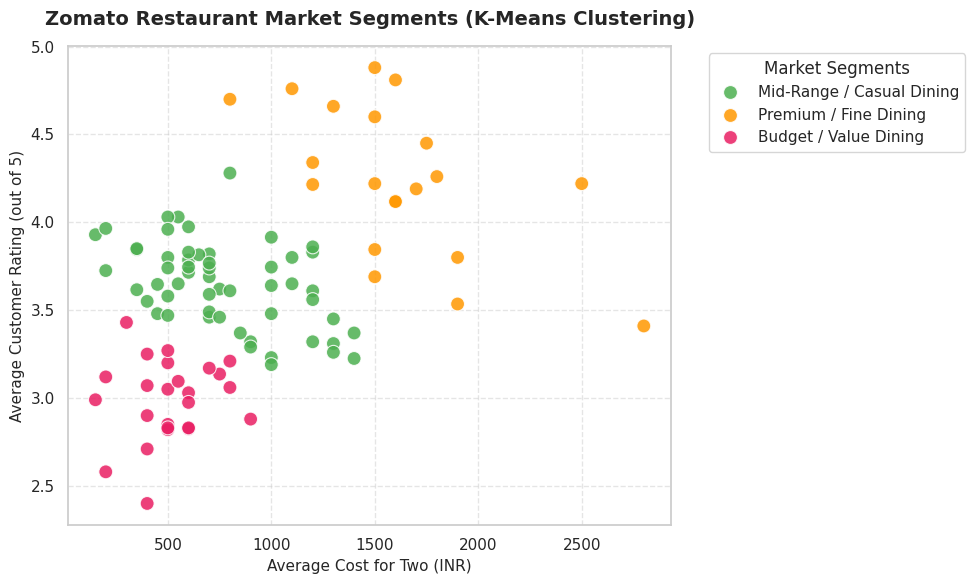

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import numpy as np

# 1. Run K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_merged['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. Get cluster centers (centroids) and sort them by cost
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
sorted_idx = np.argsort(centroids[:, 0])

# 3. Create the 'Segment' column
cluster_labels = {
    sorted_idx[0]: "Budget / Value Dining",
    sorted_idx[1]: "Mid-Range / Casual Dining",
    sorted_idx[2]: "Premium / Fine Dining"
}
df_merged['Segment'] = df_merged['Cluster'].map(cluster_labels)

# 4. Generate the Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged,
    x='Clean_Cost',
    y='Avg_Rating',
    hue='Segment',       # This will now work perfectly!
    palette=['#4CAF50', '#FF9800', '#E91E63'],
    s=100,
    alpha=0.85,
    edgecolor='w'
)

plt.title('Zomato Restaurant Market Segments (K-Means Clustering)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Cost for Two (INR)', fontsize=11)
plt.ylabel('Average Customer Rating (out of 5)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Market Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

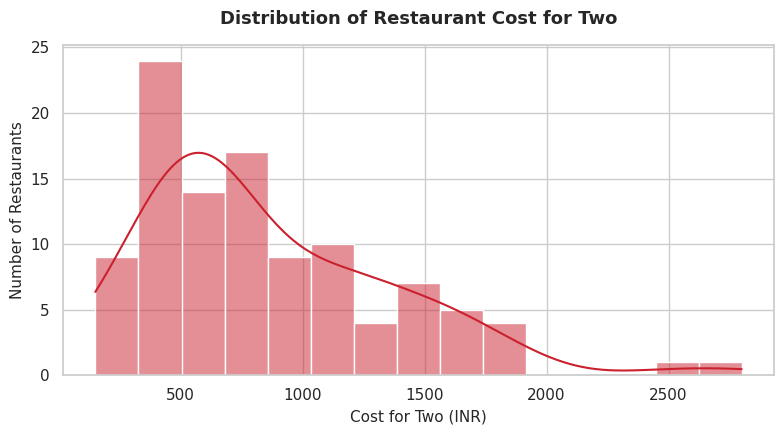

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4.5))
# Plotting histogram with a smooth density curve (KDE) in Zomato Red
sns.histplot(df_meta['Clean_Cost'], kde=True, color='#cb202d', bins=15)

plt.title('Distribution of Restaurant Cost for Two', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Cost for Two (INR)', fontsize=11)
plt.ylabel('Number of Restaurants', fontsize=11)
plt.tight_layout()
plt.show()